In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [4]:
raw_df=pd.read_csv('/content/weatherAUS[1].csv')

In [5]:
raw_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,N,13.0,7.0,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [7]:
raw_df.dropna(subset=['RainTomorrow'], inplace=True)

In [8]:
year=pd.to_datetime(raw_df.Date).dt.year

train_df=raw_df[year<2015]
val_df=raw_df[year==2015]
test_df=raw_df[year>2015]

In [9]:
input_cols=list(train_df.columns)[:-1]
target_cols='RainTomorrow'

In [10]:
input_cols

['Date',
 'Location',
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday']

In [11]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_cols].copy()

In [12]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_cols].copy()

In [13]:
test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_cols].copy()

In [14]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()
categorical_cols.remove('Date')
categorical_cols

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [15]:
from sklearn.impute import SimpleImputer

In [16]:
impute=SimpleImputer(strategy='mean')

In [17]:
impute.fit(raw_df[numeric_cols])

SimpleImputer()

In [18]:
train_inputs[numeric_cols]=impute.transform(train_df[numeric_cols])
val_inputs[numeric_cols]=impute.transform(val_df[numeric_cols])
test_inputs[numeric_cols]=impute.transform(test_df[numeric_cols])

In [19]:
from sklearn.preprocessing import MinMaxScaler

In [20]:
scalar=MinMaxScaler()

In [21]:
scalar.fit(raw_df[numeric_cols])

MinMaxScaler()

In [22]:
train_inputs[numeric_cols]=scalar.transform(train_df[numeric_cols])
val_inputs[numeric_cols]=scalar.transform(val_df[numeric_cols])
test_inputs[numeric_cols]=scalar.transform(test_df[numeric_cols])

In [23]:
from sklearn.preprocessing import OneHotEncoder

In [24]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(raw_df[categorical_cols])

In [25]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
len(encoded_cols)
train_inputs

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,2008-12-01,Albury,0.516509,0.523629,0.001617,NaN,NaN,W,0.294574,W,WNW,0.153846,0.275862,0.71,0.22,0.449587,0.4800,0.888889,NaN,0.508439,0.522073,No
1,2008-12-02,Albury,0.375000,0.565217,0.000000,NaN,NaN,WNW,0.294574,NNW,WSW,0.030769,0.252874,0.44,0.25,0.497521,0.4912,NaN,NaN,0.514768,0.570058,No
2,2008-12-03,Albury,0.504717,0.576560,0.000000,NaN,NaN,WSW,0.310078,W,WSW,0.146154,0.298851,0.38,0.30,0.447934,0.5056,NaN,0.222222,0.594937,0.548944,No
3,2008-12-04,Albury,0.417453,0.620038,0.000000,NaN,NaN,NE,0.139535,SE,E,0.084615,0.103448,0.45,0.16,0.613223,0.5712,NaN,NaN,0.533755,0.612284,No
4,2008-12-05,Albury,0.613208,0.701323,0.002695,NaN,NaN,W,0.271318,ENE,NW,0.053846,0.229885,0.82,0.33,0.500826,0.4624,0.777778,0.888889,0.527426,0.673704,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144548,2014-12-27,Uluru,0.599057,0.718336,0.000000,NaN,NaN,SSE,0.286822,ESE,SSE,0.184615,0.298851,0.22,0.13,0.555372,0.5232,NaN,NaN,0.651899,0.714012,No
144549,2014-12-28,Uluru,0.556604,0.786389,0.000000,NaN,NaN,NE,0.193798,ENE,SW,0.146154,0.229885,0.16,0.08,0.530579,0.4880,NaN,NaN,0.761603,0.771593,No
144550,2014-12-29,Uluru,0.608491,0.805293,0.000000,NaN,NaN,ESE,0.255814,ESE,SSE,0.200000,0.103448,0.15,0.08,0.519008,0.4944,NaN,NaN,0.778481,0.788868,No
144551,2014-12-30,Uluru,0.674528,0.818526,0.000000,NaN,NaN,ESE,0.286822,ESE,SSW,0.215385,0.195402,0.22,0.09,0.553719,0.5136,NaN,NaN,0.780591,0.817658,No


In [26]:
train_inputs[encoded_cols]=encoder.transform(train_df[categorical_cols])
val_inputs[encoded_cols]=encoder.transform(val_df[categorical_cols])
test_inputs[encoded_cols]=encoder.transform(test_df[categorical_cols])

<ipython-input-26-7c746eecae7d>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols]=encoder.transform(train_df[categorical_cols])
<ipython-input-26-7c746eecae7d>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols]=encoder.transform(train_df[categorical_cols])
<ipython-input-26-7c746eecae7d>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using p

In [27]:
X_train=train_inputs[numeric_cols+encoded_cols]
X_val=val_inputs[numeric_cols+encoded_cols]
X_test=test_inputs[numeric_cols+encoded_cols]

Training

In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
model=DecisionTreeClassifier(random_state=42)

In [30]:
model.fit(X_train,train_targets)

DecisionTreeClassifier(random_state=42)

In [31]:
model.score(X_train,train_targets)

0.9985149715116984

In [32]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [33]:
accuracy_score(train_targets,model.predict(X_train))

0.9985149715116984

In [34]:
val_preds=model.predict(X_val)

In [35]:
pd.value_counts(val_preds)/len(val_preds)

<ipython-input-35-033e99e94d1a>:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(val_preds)/len(val_preds)


,count
No,0.793454
Yes,0.206546


In [36]:
accuracy_score(val_preds,val_targets)

0.7957750565840636

In [37]:
no_list=['No']*len(val_targets)

In [38]:
accuracy_score(no_list,val_targets)

0.7882885497069235

In [39]:
confusion_matrix(val_targets,val_preds)

array([[11868,  1715],
       [ 1804,  1844]])

VisualiZation

In [40]:
from sklearn.tree import export_text,plot_tree

In [41]:
plt.figure(figsize=(80,20))

<Figure size 8000x2000 with 0 Axes>

<Figure size 8000x2000 with 0 Axes>

[Text(0.5, 0.875, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]'),
 Text(0.25, 0.625, 'Humidity3pm <= 0.565\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 0.583\ngini = 0.168\nsamples = 57410\nvalue = [52091, 5319]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'WindGustSpeed <= 0.318\ngini = 0.391\nsamples = 25008\nvalue = [18348, 6660]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Humidity3pm <= 0.825\ngini = 0.47\nsamples = 16570\nvalue = [6266, 10304]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Rainfall <= 0.007\ngini = 0.499\nsamples = 9136\nvalue = [4804, 4332]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Temp9am <= 0.292\ngini = 0.316\nsamples = 7434\nvalue = [1462, 5972]'),
 Text(0.8125, 0.125, '\

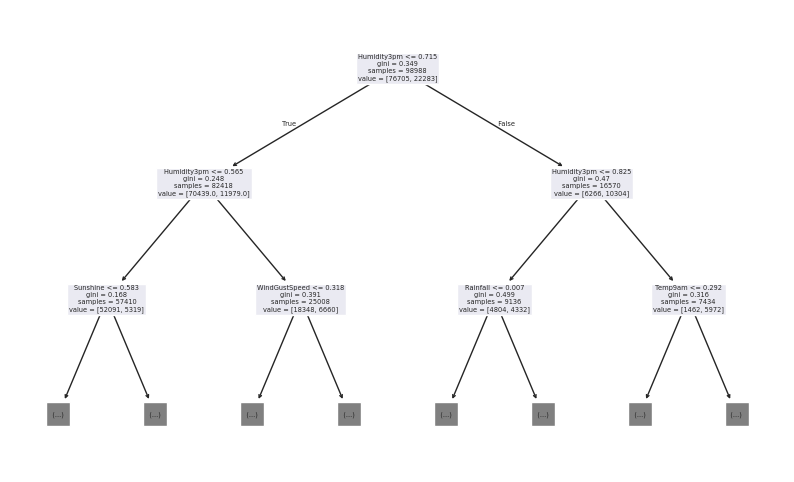

In [42]:
plot_tree(model,feature_names=X_train.columns,max_depth=2)

In [43]:
model.tree_.max_depth

47

In [44]:
text_tree=export_text(model,feature_names=list(X_train.columns),max_depth=4
                      )

In [45]:
print(text_tree)

|--- Humidity3pm <= 0.72
|   |--- Humidity3pm <= 0.56
|   |   |--- Sunshine <= 0.58
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- truncated branch of depth 27
|   |   |   |   |--- WindGustSpeed >  0.36
|   |   |   |   |   |--- truncated branch of depth 23
|   |   |   |--- Pressure3pm >  0.58
|   |   |   |   |--- WindGustSpeed <= 0.32
|   |   |   |   |   |--- truncated branch of depth 22
|   |   |   |   |--- WindGustSpeed >  0.32
|   |   |   |   |   |--- truncated branch of depth 21
|   |   |--- Sunshine >  0.58
|   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |--- Humidity3pm <= 0.44
|   |   |   |   |   |--- truncated branch of depth 37
|   |   |   |   |--- Humidity3pm >  0.44
|   |   |   |   |   |--- truncated branch of depth 33
|   |   |   |--- WindGustSpeed >  0.36
|   |   |   |   |--- Sunshine <= 0.73
|   |   |   |   |   |--- truncated branch of depth 32
|   |   |   |   |--- Sunshine >  0.73
|   |   |   |   |   |--- t

In [46]:
model.feature_importances_

array([3.52341327e-02, 3.16306443e-02, 4.71435892e-02, 2.34618165e-02,
       4.97815717e-02, 6.28966712e-02, 2.95977671e-02, 2.93403001e-02,
       3.60770760e-02, 2.75648289e-01, 3.55100349e-02, 6.45602470e-02,
       1.40601676e-02, 1.93321593e-02, 3.61710622e-02, 3.08903824e-02,
       1.91468292e-03, 1.48544941e-03, 1.63702862e-03, 6.17542324e-04,
       1.57416566e-03, 1.41943570e-03, 1.12462302e-03, 1.28990636e-03,
       7.89147891e-04, 1.49659555e-03, 1.19862325e-03, 1.73550622e-03,
       1.30243107e-03, 4.41798771e-04, 1.34303493e-03, 1.67519039e-03,
       2.85263562e-04, 1.09414352e-03, 1.04526679e-03, 8.82809883e-04,
       6.22388810e-04, 9.32999238e-04, 2.03626667e-03, 7.15435883e-04,
       1.76830924e-04, 8.66017577e-04, 1.88722266e-03, 1.95881599e-03,
       1.48742544e-03, 5.70511476e-04, 4.25453208e-04, 1.66065199e-03,
       1.30763059e-03, 1.80547322e-03, 1.04559839e-03, 1.52371288e-03,
       7.29224439e-04, 1.61243958e-03, 1.61241332e-03, 2.71641269e-04,
      

In [47]:
importance_df=pd.DataFrame({
    'features':X_train.columns,
    'importance':model.feature_importances_
}).sort_values('importance',ascending=False)

In [48]:
importance_df

,features,importance
9,Humidity3pm,0.275648
11,Pressure3pm,0.064560
5,WindGustSpeed,0.062897
4,Sunshine,0.049782
2,Rainfall,0.047144
14,Temp9am,0.036171
8,Humidity9am,0.036077
10,Pressure9am,0.035510
0,MinTemp,0.035234
1,MaxTemp,0.031631


<Axes: xlabel='importance', ylabel='features'>

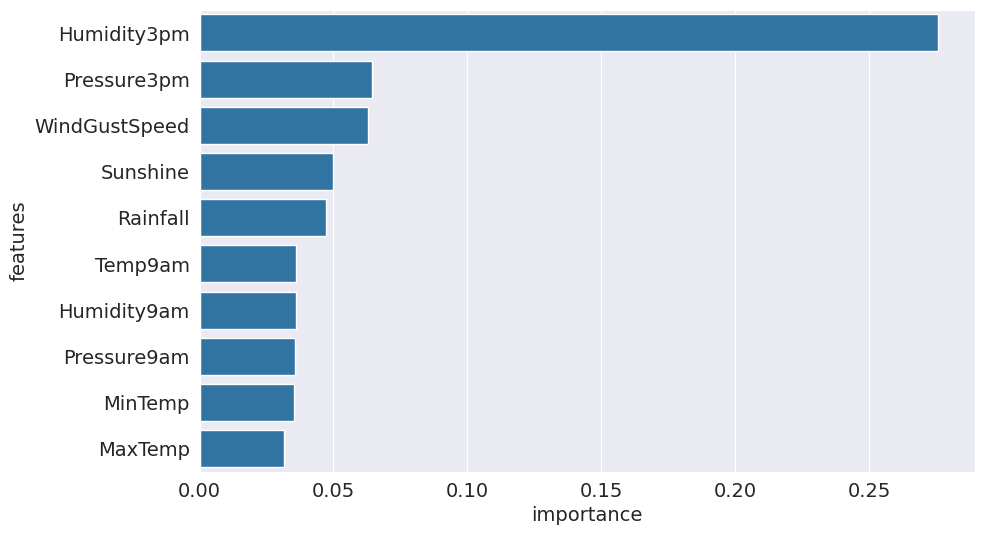

In [49]:
sns.barplot(importance_df.head(10),x='importance',y='features')

HYPERPARAMETERS


Max_depth

In [50]:
model=DecisionTreeClassifier(max_depth=3,random_state=42)

In [51]:
model.fit(X_train,train_targets)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [52]:
model.score(X_train,train_targets)

0.8290802925607145

In [53]:
model.score(X_val,val_targets)

0.8332656259067959

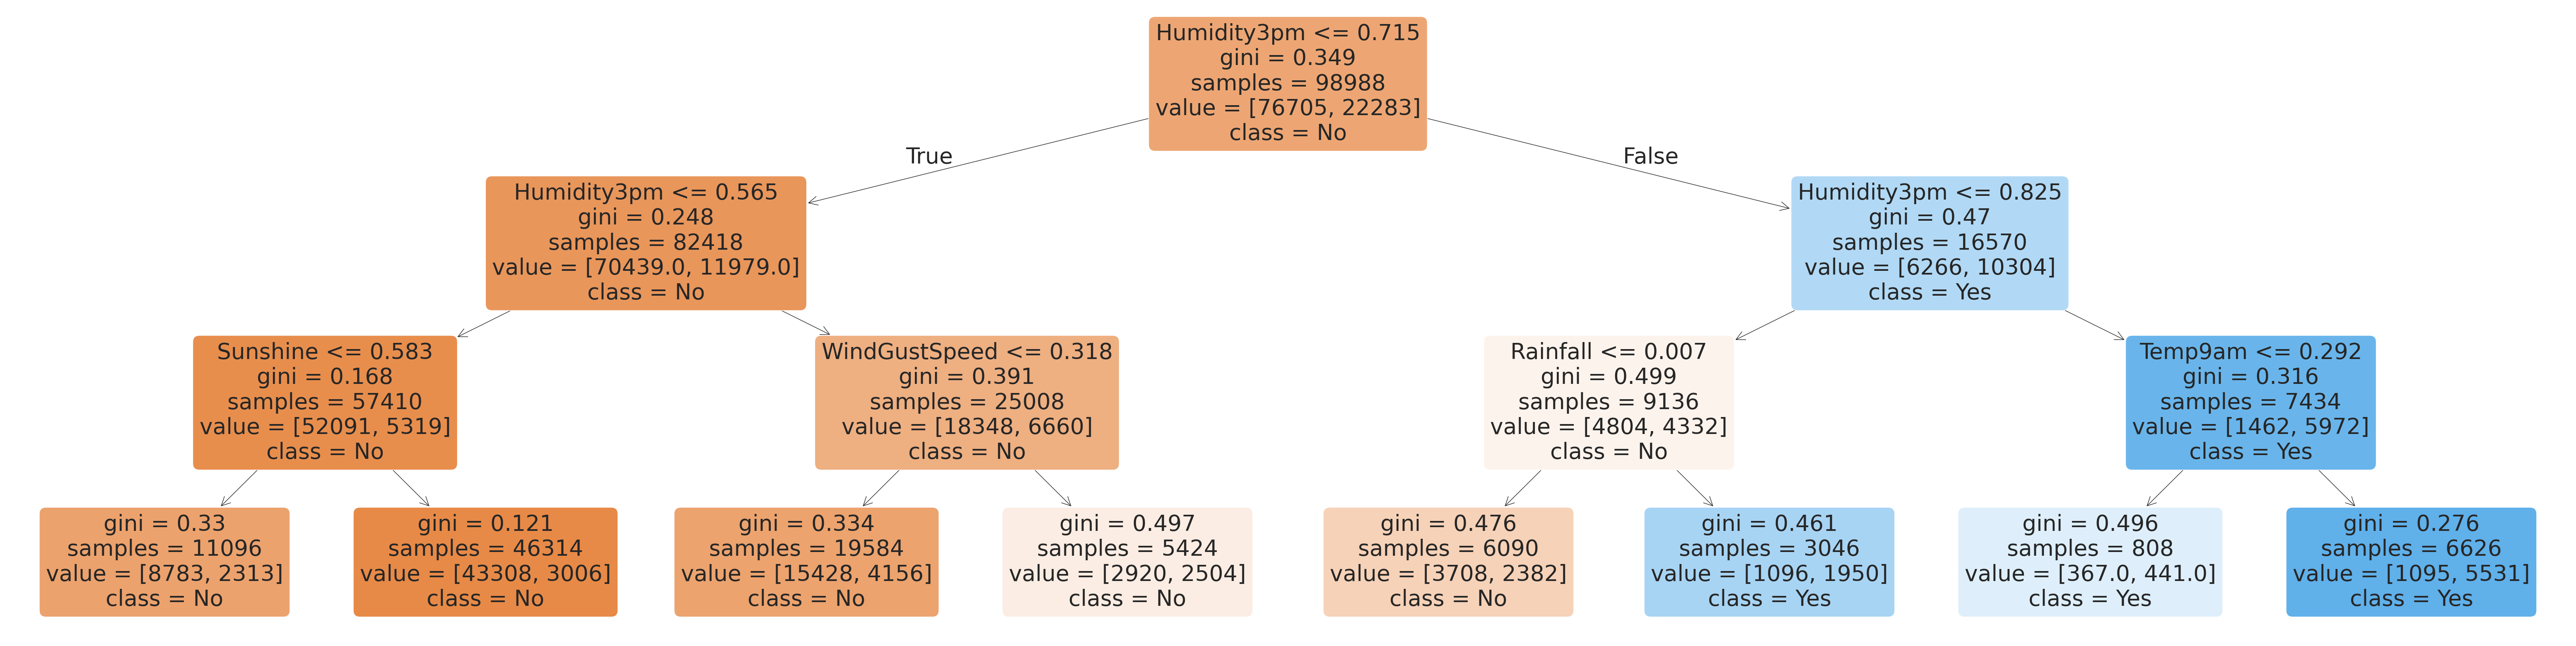

In [54]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_);

In [55]:
print(export_text(model, feature_names=list(X_train.columns)))

|--- Humidity3pm <= 0.72
|   |--- Humidity3pm <= 0.56
|   |   |--- Sunshine <= 0.58
|   |   |   |--- class: No
|   |   |--- Sunshine >  0.58
|   |   |   |--- class: No
|   |--- Humidity3pm >  0.56
|   |   |--- WindGustSpeed <= 0.32
|   |   |   |--- class: No
|   |   |--- WindGustSpeed >  0.32
|   |   |   |--- class: No
|--- Humidity3pm >  0.72
|   |--- Humidity3pm <= 0.82
|   |   |--- Rainfall <= 0.01
|   |   |   |--- class: No
|   |   |--- Rainfall >  0.01
|   |   |   |--- class: Yes
|   |--- Humidity3pm >  0.82
|   |   |--- Temp9am <= 0.29
|   |   |   |--- class: Yes
|   |   |--- Temp9am >  0.29
|   |   |   |--- class: Yes



In [56]:
def max_depth_error(n):
  model=DecisionTreeClassifier(max_depth=n,random_state=42)
  model.fit(X_train,train_targets)
  train_acc=1-model.score(X_train,train_targets)
  val_acc=1-model.score(X_val,val_targets)
  return {'Max_Depth':n,'Training_Error':train_acc,'Validation_Error':val_acc}

In [57]:
errors_df=pd.DataFrame([max_depth_error(n) for n in range(1,21)])

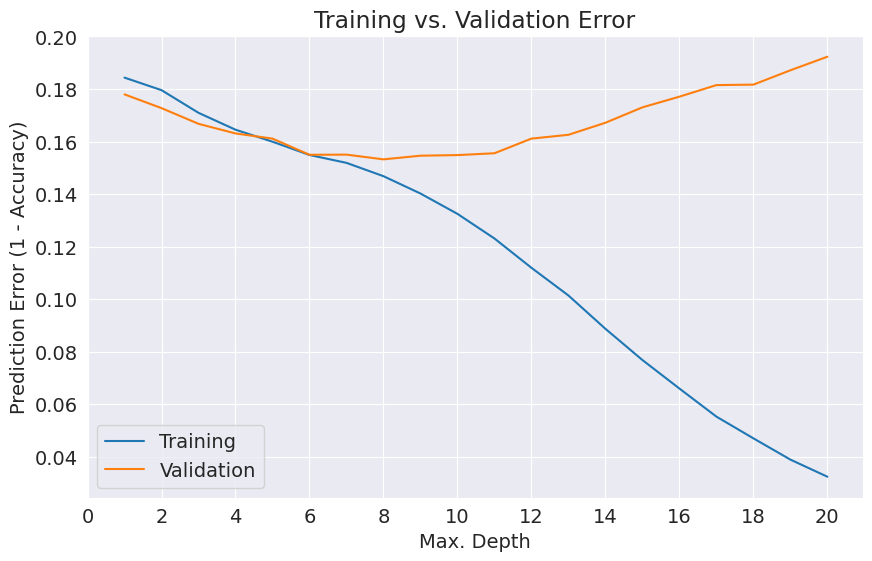

In [58]:
plt.figure()
plt.plot(errors_df['Max_Depth'], errors_df['Training_Error'])
plt.plot(errors_df['Max_Depth'], errors_df['Validation_Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])

In [59]:
model=DecisionTreeClassifier(max_depth=5,random_state=42)

In [60]:
model.fit(X_train,train_targets)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [61]:
model.score(X_val,val_targets)

0.8388950147989089

In [62]:
model.score(X_test,test_targets)

0.8286363286363286

MAX_LEAF_NODES

In [63]:
model = DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [64]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [65]:
model.score(X_train, train_targets)

0.8495575221238938

In [66]:
model.score(X_val, val_targets)

0.8444083338169578

In [67]:
model.tree_.max_depth

11

In [68]:
model_text = export_text(model, feature_names=list(X_train.columns))
print(model_text[:3000])

|--- Humidity3pm <= 0.72
|   |--- Humidity3pm <= 0.56
|   |   |--- Sunshine <= 0.58
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Humidity3pm >  0.28
|   |   |   |   |   |   |--- WindDir3pm_N <= 0.50
|   |   |   |   |   |   |   |--- Sunshine <= 0.37
|   |   |   |   |   |   |   |   |--- Pressure3pm <= 0.44
|   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |--- Pressure3pm >  0.44
|   |   |   |   |   |   |   |   |   |--- WindDir3pm_NNW <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindDir3pm_NNW >  0.50
|   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |--- Sunshine >  0.37
|   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |--- WindDir3pm_N >  0.50
|   |   |   |   |   |   |   |--- class: No
|   |   |   

Random_Forest


In [69]:
from sklearn.ensemble import RandomForestClassifier

In [70]:
model=RandomForestClassifier(n_jobs=-1,random_state=42)

In [71]:
model.fit(X_train,train_targets)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [75]:
model.score(X_train,train_targets)

0.9999595910615429

In [76]:
model.score(X_val,val_targets)

0.8576402994602751

In [78]:
train_probs=model.predict_proba(X_train)
train_probs

array([[0.93, 0.07],
       [0.99, 0.01],
       [0.98, 0.02],
       ...,
       [0.99, 0.01],
       [1.  , 0.  ],
       [0.94, 0.06]])

In [80]:
model.estimators_[0]

DecisionTreeClassifier(max_features='sqrt', random_state=1608637542)

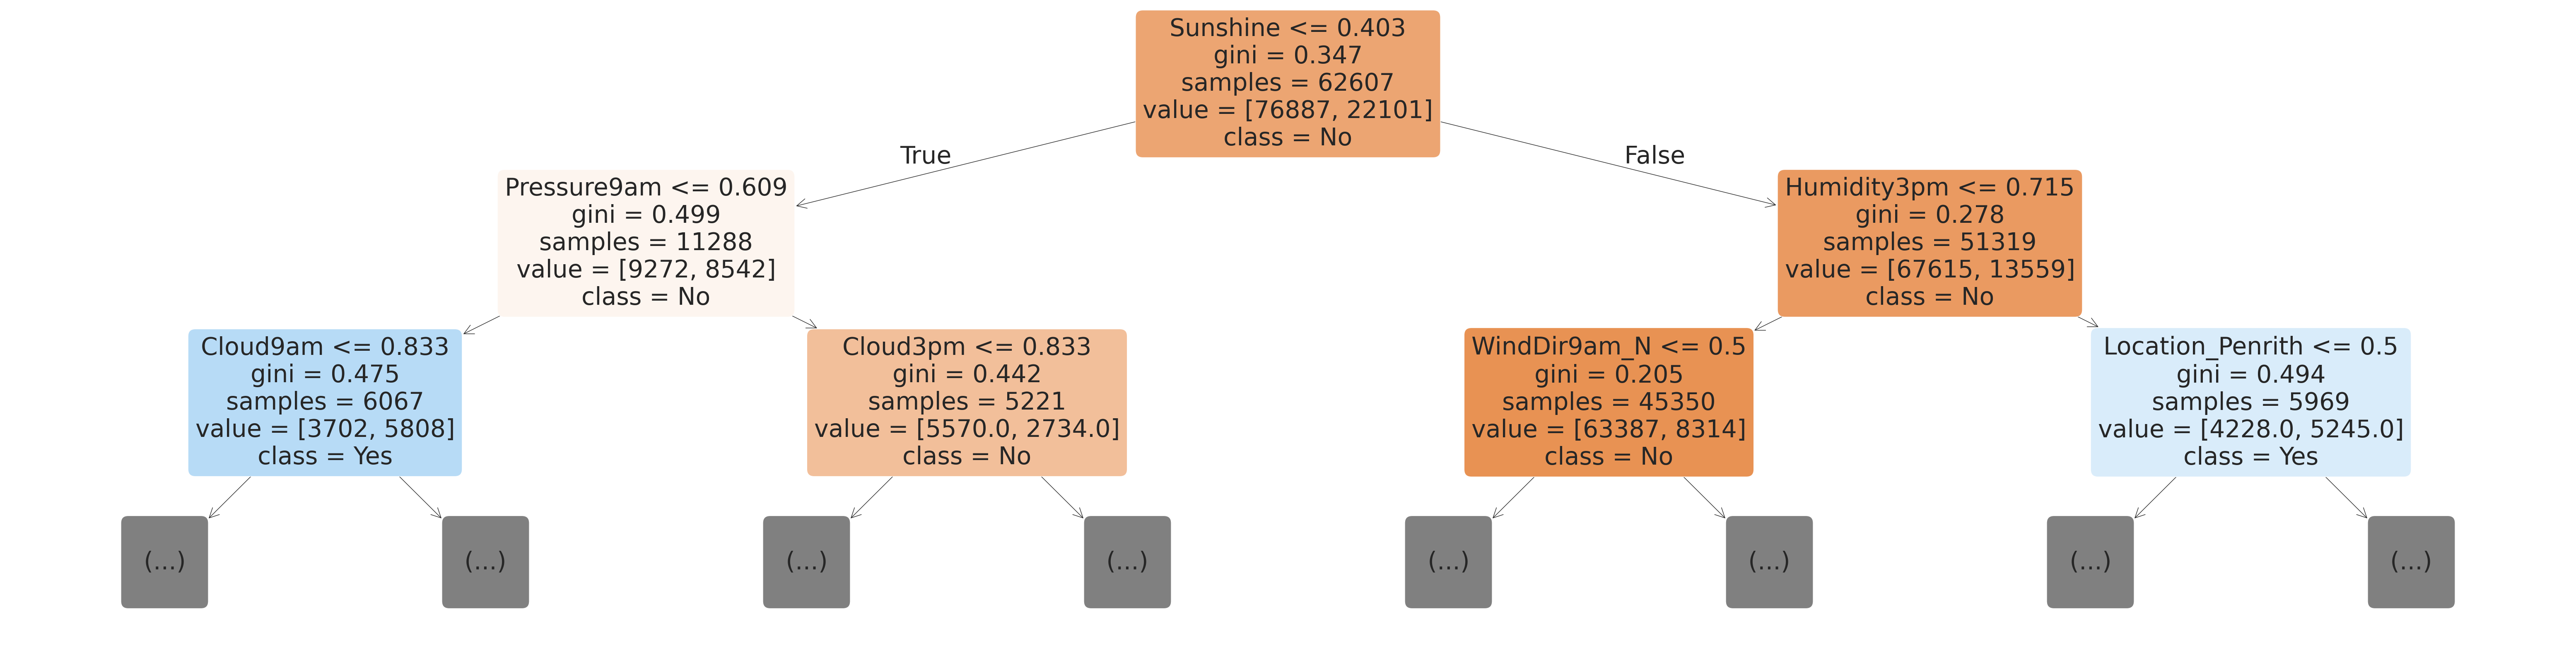

In [81]:
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[0], max_depth=2, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_);

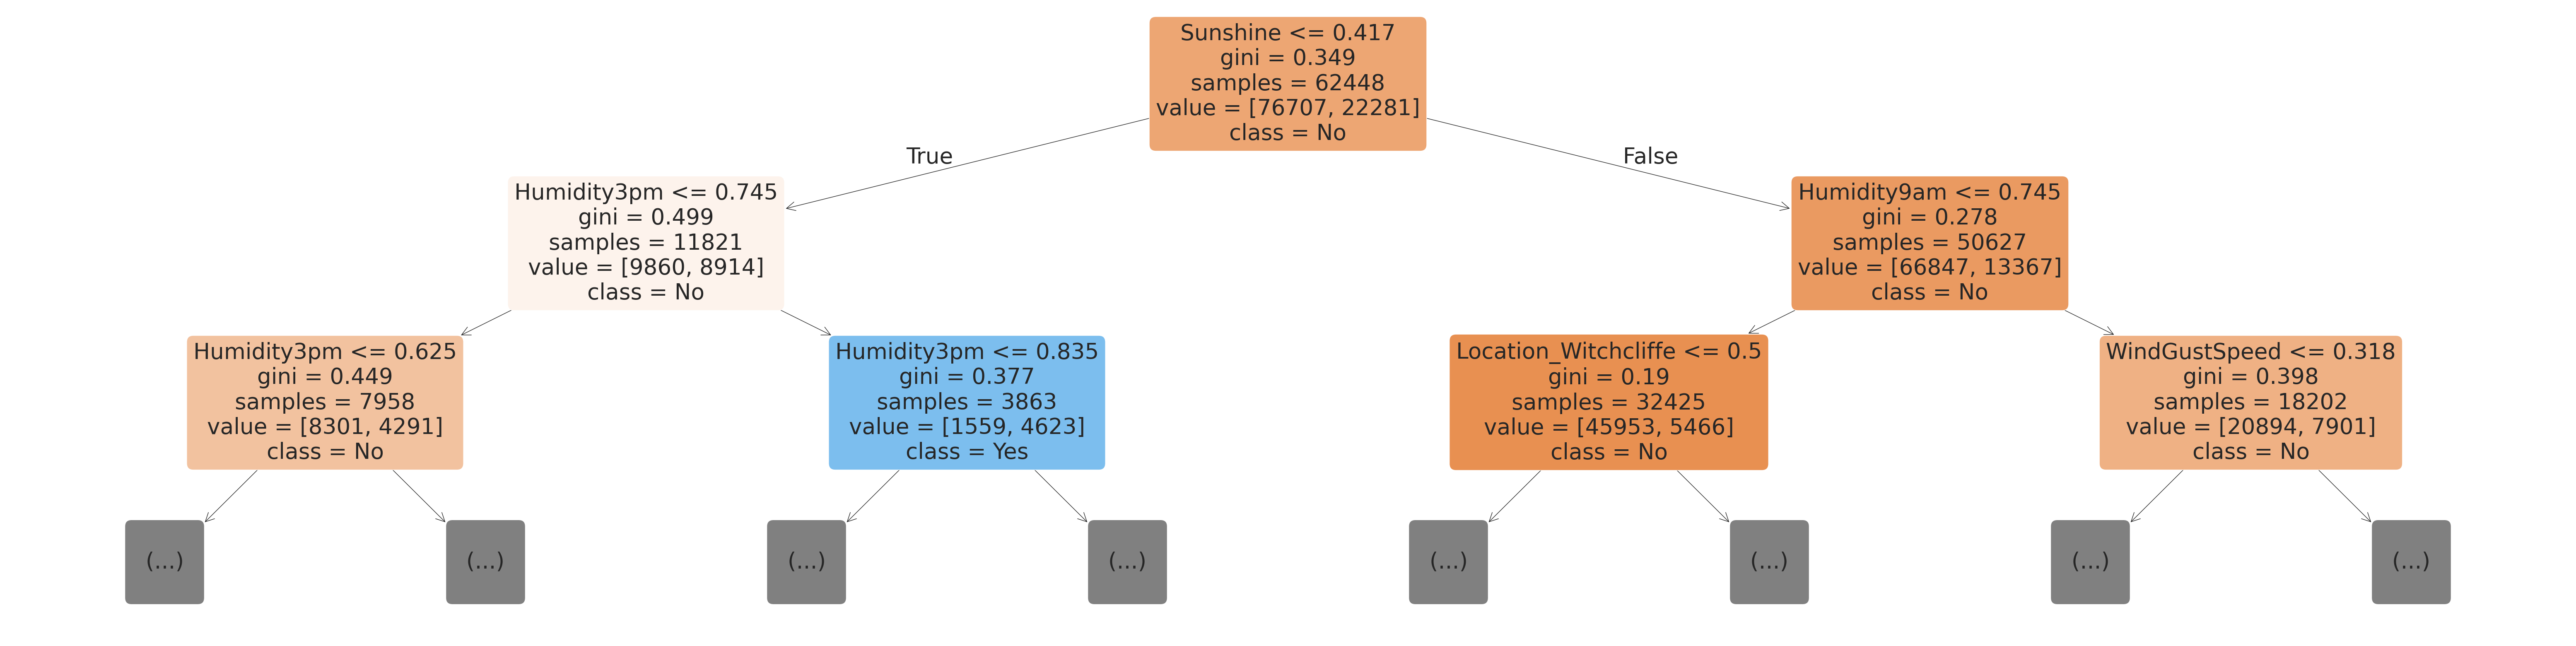

In [82]:
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[15], max_depth=2, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_);

In [83]:
len(model.estimators_)

100

In [84]:
importance_df=pd.DataFrame({
    'feature':X_train.columns,
    'importance':model.feature_importances_
}).sort_values('importance',ascending=False)

<Axes: title={'center': 'Importance vs feature'}, xlabel='importance', ylabel='feature'>

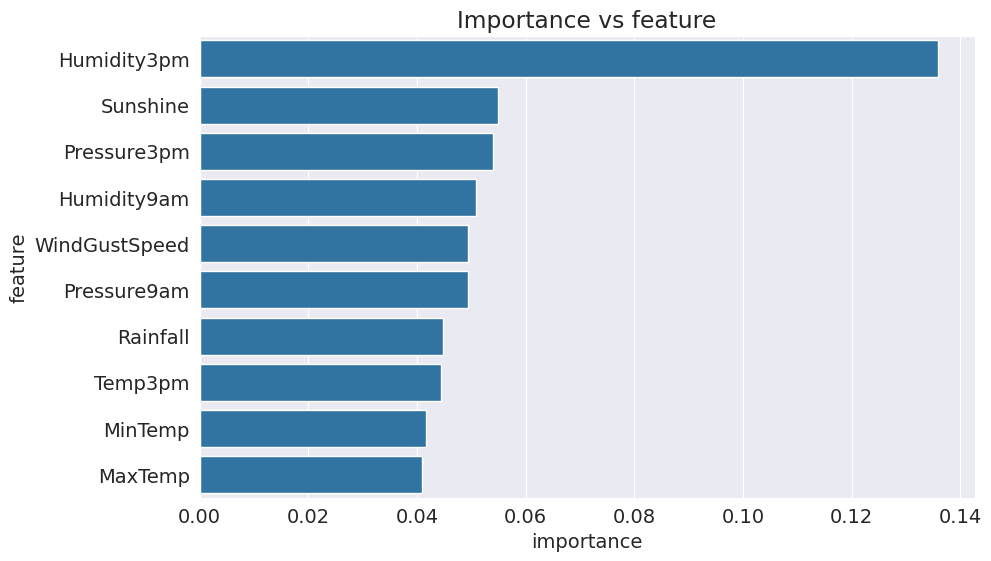

In [87]:
plt.title('Importance vs feature')
sns.barplot(importance_df.head(10),x='importance',y='feature')

HyperParameters

In [88]:
base_model=RandomForestClassifier(n_jobs=-1,random_state=42)

In [90]:
base_model.fit(X_train,train_targets)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [94]:
base_train_acc=base_model.score(X_train,train_targets)
base_val_acc=base_model.score(X_val,val_targets)

In [95]:
base_acc=base_train_acc,base_val_acc
base_acc

(0.9999595910615429, 0.8576402994602751)

n_estimators

In [101]:
def n_estimators_acc(n):
  model=RandomForestClassifier(n_jobs=-1,random_state=42,n_estimators=n)
  model.fit(X_train,train_targets)
  print('Test_acc=',model.score(X_train,train_targets),'\nVal_acc=',model.score(X_val,val_targets),'\n')

In [102]:
n_estimators_acc(10)
n_estimators_acc(100)
n_estimators_acc(500)
n_estimators_acc(1000)

Test_acc= 0.9865539257283711 
Val_acc= 0.8448145783761825 

Test_acc= 0.9999595910615429 
Val_acc= 0.8576402994602751 

Test_acc= 0.9999797955307714 
Val_acc= 0.8582786837676281 

Test_acc= 0.9999797955307714 
Val_acc= 0.8578144042713713 



Max_Features

In [105]:
def test_params(**params):
  model=RandomForestClassifier(random_state=42,n_jobs=-1,**params).fit(X_train,train_targets)
  return model.score(X_train,train_targets),model.score(X_val,val_targets)

In [106]:
test_params(max_features='log2')

(0.9999595910615429, 0.8572920898380825)

In [107]:
test_params(max_features='sqrt')

(0.9999595910615429, 0.8576402994602751)

In [108]:
test_params(max_features=5)

(0.9999393865923142, 0.856363530845569)


Max_depth , Max_leaf_Node

In [109]:
test_params(max_depth=30)

(0.9956964480543096, 0.8576402994602751)

In [110]:
test_params(max_leaf_nodes=2**10)

(0.8790964561360973, 0.853229644245836)

Min_sample_split Min_sample_leaf

In [111]:
test_params(min_samples_split=3, min_samples_leaf=2)

(0.9633086838808744, 0.8576402994602751)

In [112]:
test_params(min_samples_split=100, min_samples_leaf=60)

(0.8521032852466965, 0.847658290290755)

In [114]:
base_acc

(0.9999595910615429, 0.8576402994602751)

min_impurity_decrease

In [115]:
test_params(min_impurity_decrease=1e-6)

(0.9887360084050592, 0.8592072427601416)

In [116]:
test_params(min_impurity_decrease=1e-2)

(0.774891906089627, 0.7882885497069235)

In [117]:
base_acc

(0.9999595910615429, 0.8576402994602751)

bootstrap,max_samples

In [118]:
test_params(bootstrap=False)

(0.9999797955307714, 0.8603679415007834)

In [120]:
base_acc

(0.9999595910615429, 0.8576402994602751)

In [121]:
test_params(max_samples=0.9)

(0.9997373419000283, 0.8582786837676281)

In [122]:
test_params(class_weight='balanced')

(0.9999494888269285, 0.8555510417271197)

In [123]:
test_params(class_weight={'No': 1, 'Yes': 2})

(0.9999494888269285, 0.8555510417271197)